## Dynamic Risk-Budgeting Portfolio

In [159]:
import numpy as np
import pandas as pd
import quant_risk_kit as erk
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
n_scenarios = 1000
rates, zc_prices = erk.cir(10, n_scenarios=n_scenarios, b=0.03, r_0 = 0.03, sigma=0.02)
price_eq = erk.gbm(n_years=10,n_scenarios=n_scenarios, mu=0.07, sigma=0.15)
rets_eq = price_eq.pct_change().dropna()
rets_zc = zc_prices.pct_change().dropna()
cashrate = 0.02
monthly_cashreturn = (1+cashrate)**(1/12) - 1
rets_cash = pd.DataFrame(data= monthly_cashreturn, index=rets_eq.index, columns=rets_eq.columns)
liabilities = pd.DataFrame(data= 0, index=rets_zc.index, columns=rets_zc.columns)
liabilities.loc[60] = 100
liabilities.loc[72] = 100
liabilities.loc[84] = 100
liabilities.loc[96] = 100
liabilities.loc[108] = 100
liabilities.loc[120] = 100
pv = (liabilities * zc_prices).sum(axis = 0)
a_0=pv.mean()

In [62]:
rets_7030b = erk.bt_mix(rets_eq, rets_zc, allocator=erk.fixedmix_allocator, w1=0.7)
rets_floor75 = erk.bt_mix(rets_eq, rets_zc, allocator=erk.floor_allocator, floor=.75,  zc_prices=zc_prices[1:])
rets_floor75m1 = erk.bt_mix(rets_eq, rets_zc, allocator=erk.floor_allocator, floor=.75,  zc_prices=zc_prices[1:], m=1)
rets_floor75m5 = erk.bt_mix(rets_eq, rets_zc, allocator=erk.floor_allocator, floor=.75,  zc_prices=zc_prices[1:], m=5)
rets_maxdd25 = erk.bt_mix(rets_eq, rets_zc, allocator=erk.drawdown_allocator, maxdd=.25)
rets_gd_fl = erk.bt_mix(rets_eq, rets_zc, allocator= erk.glidem_floor_allocator, floor =0.75, zc_prices = zc_prices[1:], m_start = 3, m_end= 1)
rets_gd_dd = erk.bt_mix(rets_eq, rets_zc, allocator= erk.glidem_drawdown_allocator, maxdd = 0.20, m_start = 10, m_end= 5)
tv_maxdd25 = erk.terminal_values(rets_maxdd25)

In [63]:
stats = pd.concat([erk.terminal_stats(rets_zc, name="ZC", floor=0.75), 
           erk.terminal_stats(rets_eq, name="Eq", floor=0.75),
           erk.terminal_stats(rets_7030b, name="70/30", floor=0.75),
           erk.terminal_stats(rets_floor75, name="Floor75", floor=0.75),
           erk.terminal_stats(rets_floor75m1, name="Floor75m1", floor=0.75),
           erk.terminal_stats(rets_floor75m5, name="Floor75m5", floor=0.75),
           erk.terminal_stats(rets_gd_fl, name="Glide Floor", floor=0.75),
           erk.terminal_stats(rets_maxdd25, name="MaxDD25", floor=0.75),   
           erk.terminal_stats(rets_gd_dd, name="Glide Drawdown", floor=0.75)           
          ],
          axis=1).round(6)

In [149]:
stats

,ZC,Eq,70/30,Floor75,Floor75m1,Floor75m5,Glide Floor,MaxDD25,Glide Drawdown
mean,1.343337,1.961457,1.754798,1.938029,1.618156,1.948906,1.864414,1.692514,1.755452
std,0.000000,0.944371,0.573101,0.950950,0.416593,0.951649,0.900938,0.536437,0.776734
p_breach,NaN,0.034000,0.010000,NaN,NaN,NaN,NaN,NaN,NaN
e_short,NaN,0.122834,0.074520,NaN,NaN,NaN,NaN,NaN,NaN
p_reach,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
e_surplus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dd_breach,NaN,0.638000,0.213000,0.619000,0.008000,0.635000,0.480000,NaN,NaN


Text(0.5, 1.0, 'Funding Ratio by comparison of different LDI Strategies')

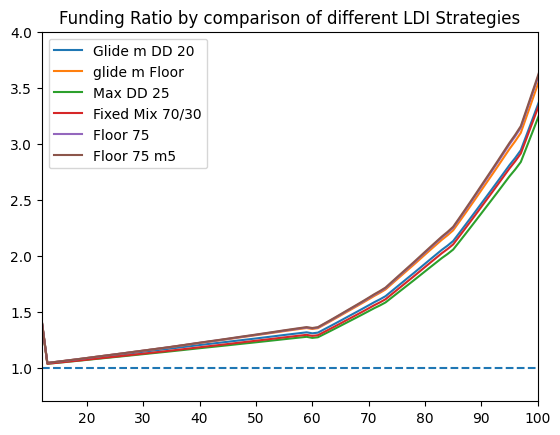

In [65]:
erk.ldi_funding_ratio(rets_gd_dd, liabilities, zc_prices, a_0, True).plot(label= "Glide m DD 20",legend=True)
erk.ldi_funding_ratio(rets_gd_fl, liabilities, zc_prices, a_0, True).plot(label="glide m Floor", legend=True)
erk.ldi_funding_ratio(rets_maxdd25, liabilities, zc_prices, a_0, True).plot(label="Max DD 25",legend=True)
erk.ldi_funding_ratio(rets_7030b, liabilities, zc_prices, a_0, True).plot(label="Fixed Mix 70/30", legend=True)
erk.ldi_funding_ratio(rets_floor75, liabilities, zc_prices, a_0, True).plot(label="Floor 75", legend=True)
erk.ldi_funding_ratio(rets_floor75m5, liabilities, zc_prices, a_0, True).plot(label="Floor 75 m5", legend=True)
erk.plt.axhline(1.00, linestyle = "--")
plt.xlim(12,100)
plt.ylim(0.7, 4.0)
#plt.size(15,6)
plt.title("Funding Ratio by comparison of different LDI Strategies")

# Stress Testing

In [123]:
# 1. Copy original returns to avoid overwriting base scenarios
rets_eq_stressed = rets_eq.copy()

# 2. Define shock parameters
crash_month = 10       # Month 10 (when m ~ 10 and risk budget is maxed out)
crash_magnitude = -0.35 # -35% equity crash in a single month

# 3. Apply shock across all Monte Carlo paths at t = 10
rets_eq_stressed.iloc[10] = -0.10
rets_eq_stressed.iloc[11] = -0.15
rets_eq_stressed.iloc[12] = -0.20
rets_eq_stressed.iloc[13] = -0.25
rets_eq_stressed.iloc[14] = -0.30
rets_eq_stressed.iloc[15] = -0.22

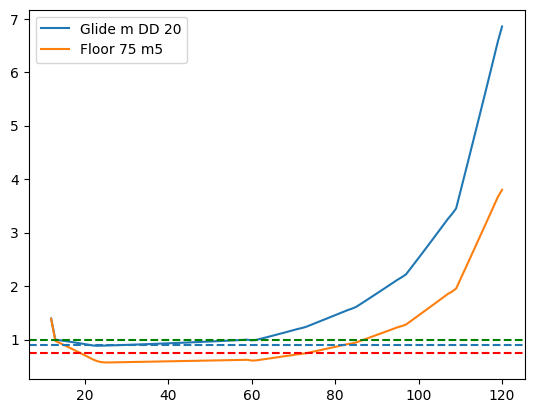

In [125]:
rets_gd_dd_test = erk.bt_mix(rets_eq_stressed, rets_zc, allocator= erk.glidem_drawdown_allocator, maxdd = 0.20, m_start = 10, m_end= 5)
rets_floor75m5_test = erk.bt_mix(rets_eq_stressed, rets_zc, allocator=erk.floor_allocator, floor=.75,  zc_prices=zc_prices[1:], m=5)
erk.ldi_funding_ratio(rets_gd_dd_test, liabilities, zc_prices, a_0, True).plot(label= "Glide m DD 20",legend=True)
erk.ldi_funding_ratio(rets_floor75m5_test, liabilities, zc_prices, a_0, True).plot(label= "Floor 75 m5",legend=True)
#erk.drawdown(rets_eq_stressed[1])["Drawdown"].plot()
plt.axhline(1.00, linestyle = "--", color="green")
plt.axhline(0.90, linestyle = "--")
plt.axhline(0.75, linestyle = "--", color="red")

<Axes: >

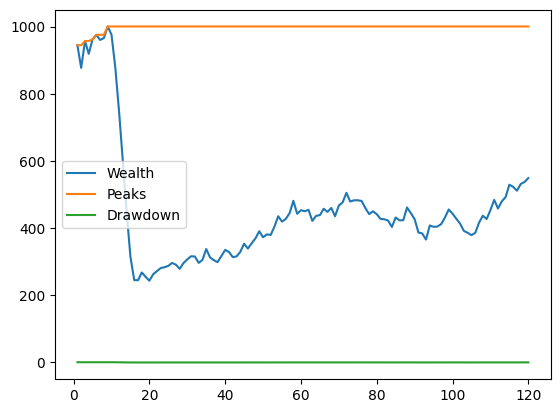

In [126]:
erk.drawdown(pd.Series(rets_eq_stressed[1])).plot()

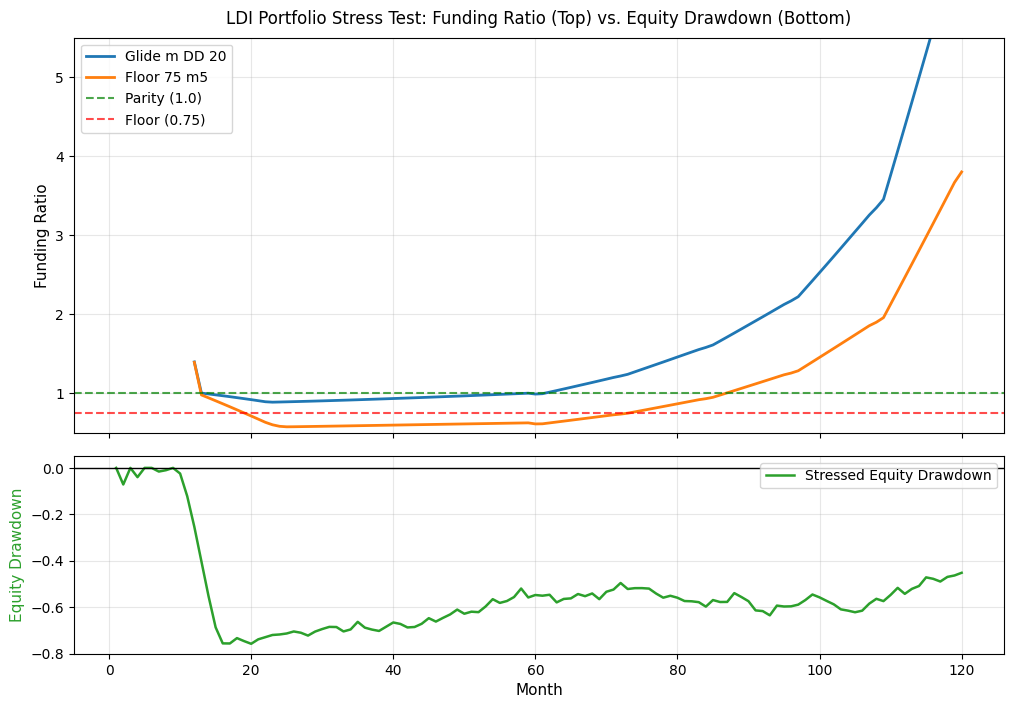

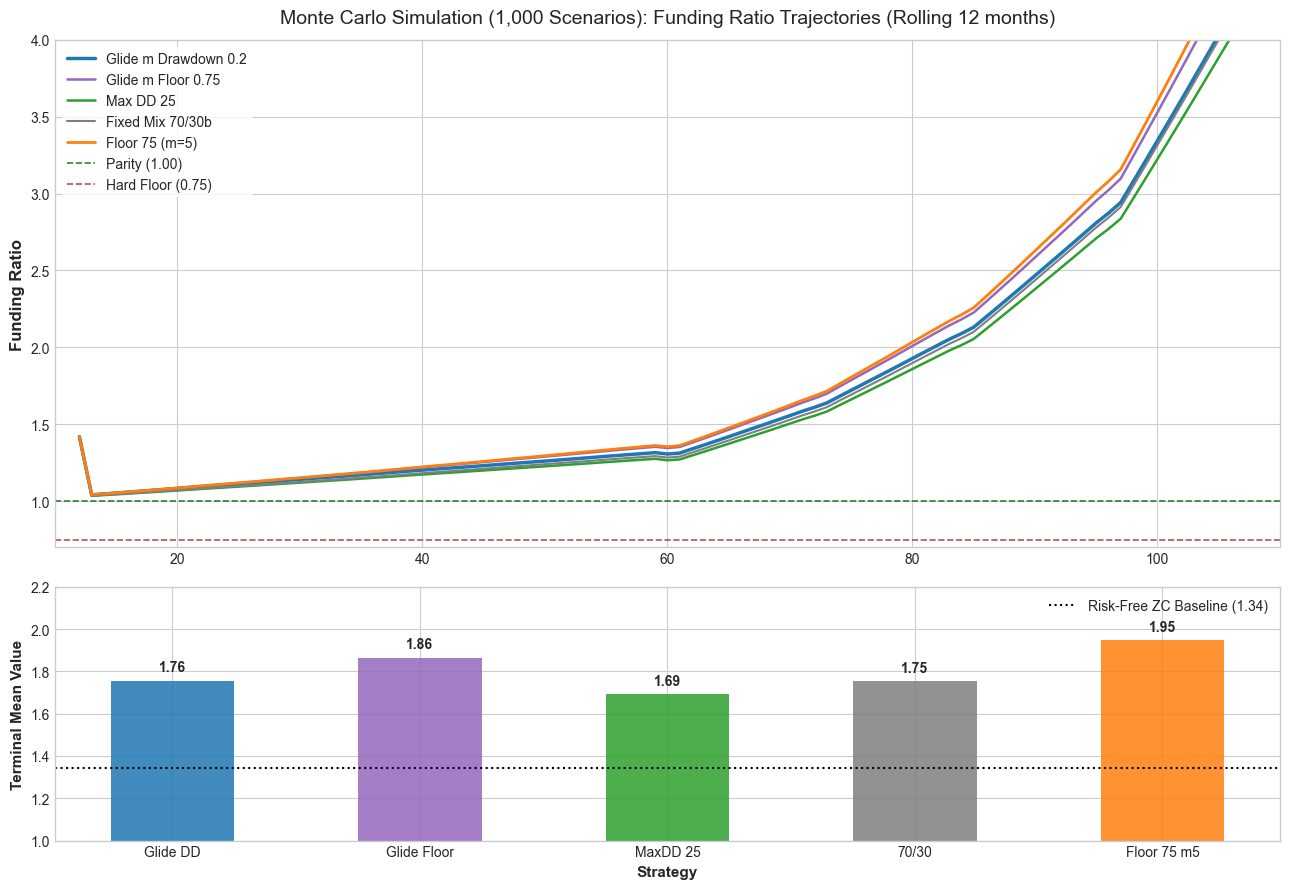

In [156]:
# Set publication style
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios': [2, 1]})

# --- TOP PANEL: Multi-Strategy Funding Ratio Trajectories ---
strategies = {
    'Glide m Drawdown 0.2': (rets_gd_dd, 'tab:blue', 2.5),
    'Glide m Floor 0.75': (rets_gd_fl, 'tab:purple', 1.8),
    'Max DD 25': (rets_maxdd25, 'tab:green', 1.8),
    'Fixed Mix 70/30b': (rets_7030b, 'tab:gray', 1.5),
    'Floor 75 (m=5)': (rets_floor75m5, 'tab:orange', 2.0)
}

for name, (data, color, lw) in strategies.items():
    fr = erk.ldi_funding_ratio(data, liabilities, zc_prices, a_0, rolling=True)
    ax1.plot(fr, label=name, color=color, linewidth=lw)

# Reference Lines
ax1.axhline(1.00, linestyle='--', color='darkgreen', linewidth=1.2, alpha=0.8, label='Parity (1.00)')
ax1.axhline(0.75, linestyle='--', color='firebrick', linewidth=1.2, alpha=0.8, label='Hard Floor (0.75)')

ax1.set_ylabel('Funding Ratio', fontsize=12, fontweight='bold')
ax1.set_title('Monte Carlo Simulation (1,000 Scenarios): Funding Ratio Trajectories (Rolling 12 months)', fontsize=14, pad=12)
ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax1.set_ylim(0.70, 4.0)
ax1.set_xlim(10,110)

# --- BOTTOM PANEL: Terminal Value Distributions ---
terminal_data = [
    stats.loc['mean', 'Glide Drawdown'],
    stats.loc['mean', 'Glide Floor'],
    stats.loc['mean', 'MaxDD25'],
    stats.loc['mean', '70/30'],
    stats.loc['mean', 'Floor75m5']
]
labels = ['Glide DD', 'Glide Floor', 'MaxDD 25', '70/30', 'Floor 75 m5']
colors = ['tab:blue', 'tab:purple', 'tab:green', 'tab:gray', 'tab:orange']

bars = ax2.bar(labels, terminal_data, color=colors, alpha=0.85, width=0.5)
ax2.axhline(stats.loc['mean', 'ZC'], color='black', linestyle=':', label=f"Risk-Free ZC Baseline ({stats.loc['mean', 'ZC']:.2f})")

# Add data labels
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.03, f'{yval:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('Terminal Mean Value', fontsize=11, fontweight='bold')
ax2.set_xlabel('Strategy', fontsize=11, fontweight='bold')
ax2.set_ylim(1.0, 2.2)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Funding_Ratio_Trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

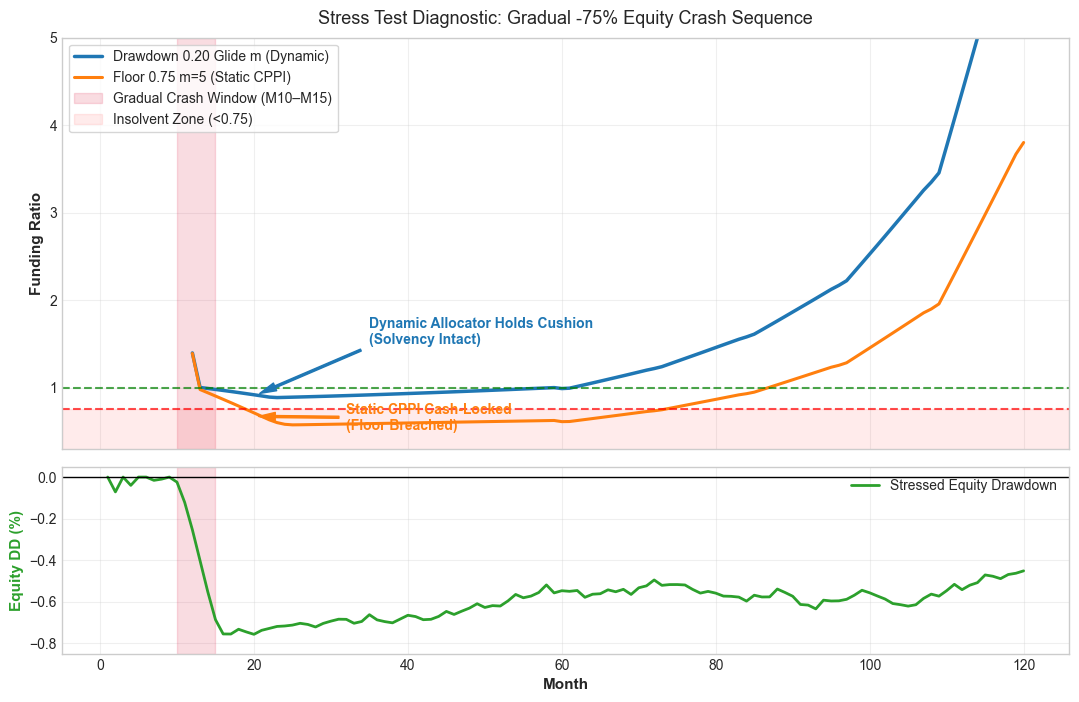

In [157]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={'height_ratios': [2.2, 1]})

# --- TOP PANEL: Funding Ratio Under Gradual Crash ---
fr_glide = erk.ldi_funding_ratio(rets_gd_dd_test, liabilities, zc_prices, a_0, rolling=True)
fr_floor = erk.ldi_funding_ratio(rets_floor75m5_test, liabilities, zc_prices, a_0, rolling=True)

ax1.plot(fr_glide, label='Drawdown 0.20 Glide m (Dynamic)', color='tab:blue', linewidth=2.5)
ax1.plot(fr_floor, label='Floor 0.75 m=5 (Static CPPI)', color='tab:orange', linewidth=2.2)

# Shaded Stress Zone & Solvency Bands
ax1.axvspan(10, 15, color='crimson', alpha=0.15, label='Gradual Crash Window (M10–M15)')
ax1.axhspan(0.0, 0.75, color='red', alpha=0.08, label='Insolvent Zone (<0.75)')

ax1.axhline(1.00, linestyle='--', color='green', alpha=0.7)
ax1.axhline(0.75, linestyle='--', color='red', alpha=0.7)

# Static CPPI Arrow (Points exactly to orange curve at Month 20)
ax1.annotate('Static CPPI Cash-Locked\n(Floor Breached)', 
             xy=(20, m20_floor_y), 
             xytext=(32, m20_floor_y - 0.15),
             arrowprops=dict(facecolor='tab:orange', edgecolor='tab:orange', shrink=0.05, width=1.5, headwidth=6),
             fontsize=10, fontweight='bold', color='tab:orange')

# Dynamic Glide Arrow (Points exactly to blue curve at Month 20)
ax1.annotate('Dynamic Allocator Holds Cushion\n(Solvency Intact)', 
             xy=(20, m20_glide_y), 
             xytext=(35, m20_glide_y + 0.60),
             arrowprops=dict(facecolor='tab:blue', edgecolor='tab:blue', shrink=0.05, width=1.5, headwidth=6),
             fontsize=10, fontweight='bold', color='tab:blue')

ax1.set_ylabel('Funding Ratio', fontsize=11, fontweight='bold')
ax1.set_title('Stress Test Diagnostic: Gradual -75% Equity Crash Sequence', fontsize=13, pad=10)
ax1.legend(loc='upper left', frameon=True)
ax1.set_ylim(0.3, 5.0)
ax1.grid(True, alpha=0.3)

# --- BOTTOM PANEL: Equity Market Drawdown ---
eq_dd = erk.drawdown(rets_eq_stressed[1])["Drawdown"]
ax2.plot(eq_dd, color='tab:green', linewidth=2, label='Stressed Equity Drawdown')
ax2.axvspan(10, 15, color='crimson', alpha=0.15)
ax2.axhline(0.0, color='black', linestyle='-', linewidth=1.0)

ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Equity DD (%)', color='tab:green', fontsize=11, fontweight='bold')
ax2.set_ylim(-0.85, 0.05)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.subplots_adjust(hspace=0.06)
plt.savefig('Stress_Test_FR.png', dpi=300, bbox_inches='tight')
plt.show()

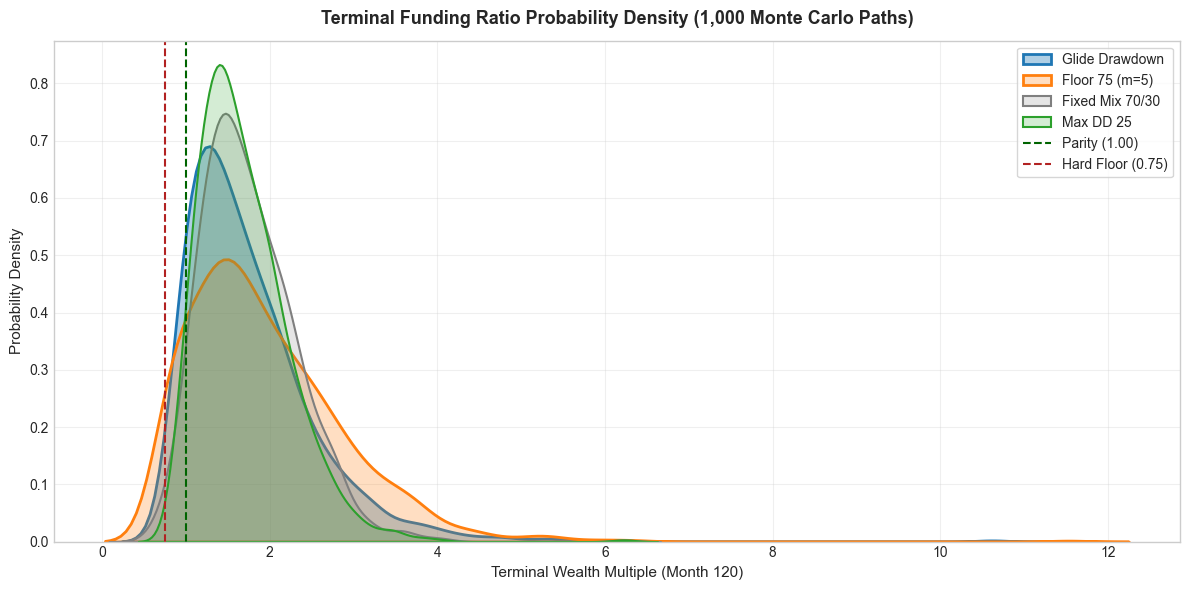

In [148]:
# Extract terminal portfolio values across all 1,000 individual scenario paths (Series of 1,000 values)
fr_glide_term = (1 + rets_gd_dd).cumprod().iloc[-1]
fr_floor_term = (1 + rets_floor75m5).cumprod().iloc[-1]
fr_7030_term  = (1 + rets_7030b).cumprod().iloc[-1]
fr_maxdd_term = (1 + rets_maxdd25).cumprod().iloc[-1]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot Kernel Density Estimations (KDE)
sns.kdeplot(fr_glide_term, label="Glide Drawdown", color="tab:blue", fill=True, alpha=0.35, linewidth=2, ax=ax)
sns.kdeplot(fr_floor_term, label="Floor 75 (m=5)", color="tab:orange", fill=True, alpha=0.25, linewidth=2, ax=ax)
sns.kdeplot(fr_7030_term,  label="Fixed Mix 70/30", color="tab:gray", fill=True, alpha=0.20, linewidth=1.5, ax=ax)
sns.kdeplot(fr_maxdd_term, label="Max DD 25", color="tab:green", fill=True, alpha=0.20, linewidth=1.5, ax=ax)

# Reference Floor Lines
ax.axvline(1.00, linestyle="--", color="darkgreen", linewidth=1.5, label="Parity (1.00)")
ax.axvline(0.75, linestyle="--", color="firebrick", linewidth=1.5, label="Hard Floor (0.75)")

ax.set_title("Terminal Funding Ratio Probability Density (1,000 Monte Carlo Paths)", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Terminal Wealth Multiple (Month 120)", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.legend(loc="upper right", frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Funding_Ratio_Trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

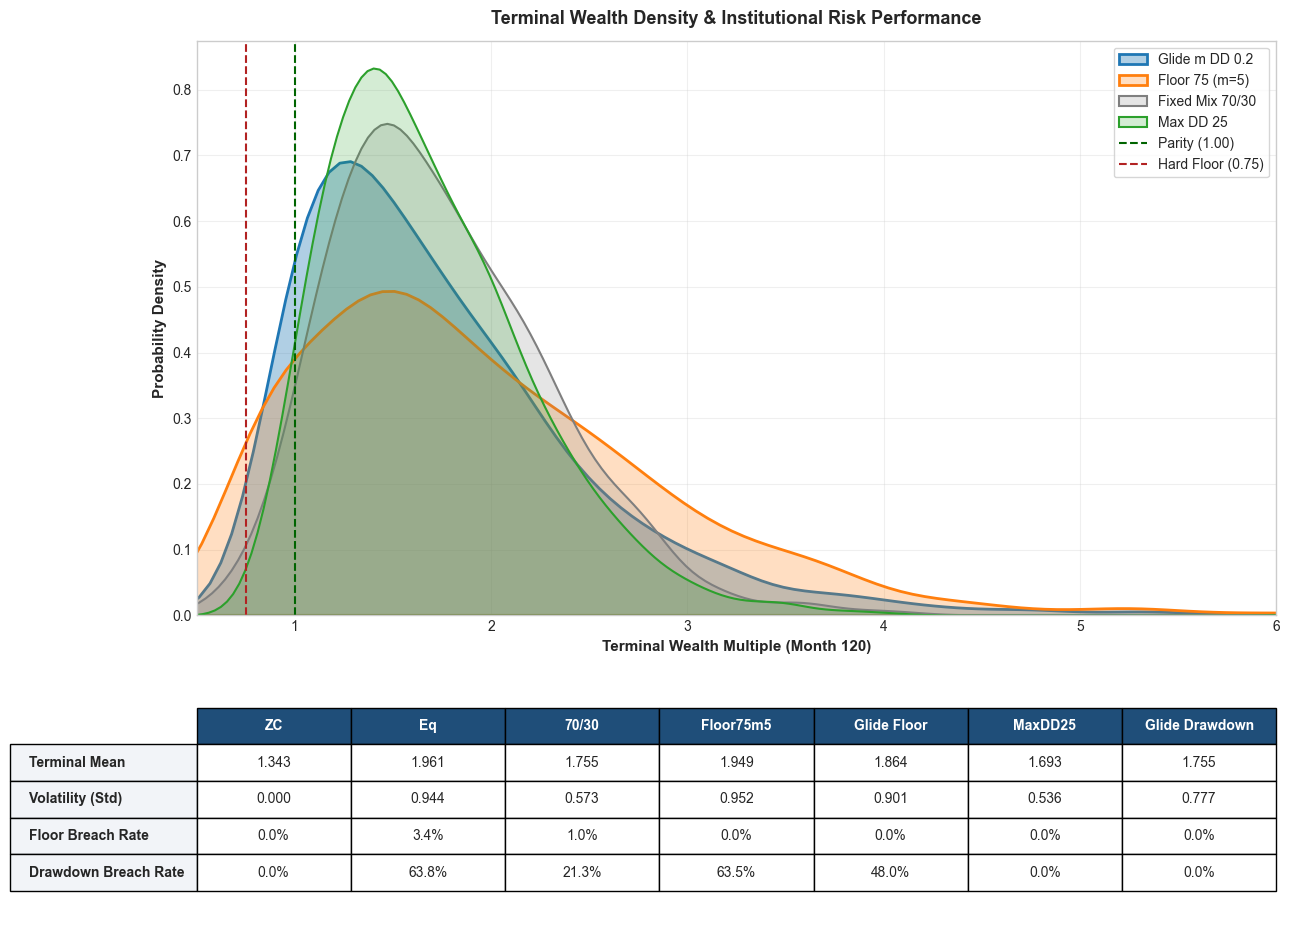

In [158]:
# 1. Filter key strategies and relevant performance metrics
selected_cols = ['ZC', 'Eq', '70/30', 'Floor75m5', 'Glide Floor', 'MaxDD25', 'Glide Drawdown']
selected_metrics = ['mean', 'std', 'p_breach', 'dd_breach']
row_labels = ['Terminal Mean', 'Volatility (Std)', 'Floor Breach Rate', 'Drawdown Breach Rate']

# 2. Format cell values cleanly (convert probabilities to % and handle NaNs)
cell_text = []
for metric in selected_metrics:
    row_vals = []
    for col in selected_cols:
        val = stats.loc[metric, col]
        if pd.isna(val):
            row_vals.append("0.0%")
        elif metric in ['p_breach', 'dd_breach']:
            row_vals.append(f"{val*100:.1f}%")
        else:
            row_vals.append(f"{val:.3f}")
    cell_text.append(row_vals)

# 3. Create vertical 2-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9.5), gridspec_kw={'height_ratios': [2.2, 1]})

# --- TOP PANEL: KDE Probability Distributions ---
fr_glide_term = (1 + rets_gd_dd).cumprod().iloc[-1]
fr_floor_term = (1 + rets_floor75m5).cumprod().iloc[-1]
fr_7030_term  = (1 + rets_7030b).cumprod().iloc[-1]
fr_maxdd_term = (1 + rets_maxdd25).cumprod().iloc[-1]

sns.kdeplot(fr_glide_term, label="Glide m DD 0.2", color="tab:blue", fill=True, alpha=0.35, linewidth=2, ax=ax1)
sns.kdeplot(fr_floor_term, label="Floor 75 (m=5)", color="tab:orange", fill=True, alpha=0.25, linewidth=2, ax=ax1)
sns.kdeplot(fr_7030_term,  label="Fixed Mix 70/30", color="tab:gray", fill=True, alpha=0.20, linewidth=1.5, ax=ax1)
sns.kdeplot(fr_maxdd_term, label="Max DD 25", color="tab:green", fill=True, alpha=0.20, linewidth=1.5, ax=ax1)

# Floor Threshold Reference Lines
ax1.axvline(1.00, linestyle="--", color="darkgreen", linewidth=1.5, label="Parity (1.00)")
ax1.axvline(0.75, linestyle="--", color="firebrick", linewidth=1.5, label="Hard Floor (0.75)")

ax1.set_title("Terminal Wealth Density & Institutional Risk Performance", fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel("Terminal Wealth Multiple (Month 120)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Probability Density", fontsize=11, fontweight='bold')
ax1.set_xlim(0.5, 6.0)
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, alpha=0.3)

# --- BOTTOM PANEL: Formatted Statistics Table ---
ax2.axis('off')  # Hide panel ticks/borders

tab = ax2.table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=selected_cols,
    cellLoc='center',
    loc='center'
)

# Style table dimensions and typography
tab.auto_set_font_size(False)
tab.set_fontsize(10)
tab.scale(1.0, 1.75)

# Highlight header and metric label background shades
for (row, col), cell in tab.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1F4E79')  # Navy header background
        cell.set_text_props(color='white', fontweight='bold')
    elif col == -1:
        cell.set_facecolor('#F2F4F8')  # Subtle gray label row
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#FFFFFF')

plt.tight_layout()
plt.savefig('Wealth_PD_stats.png', dpi=300, bbox_inches='tight')
plt.show()